# 04. MiniResNet (subclassing API, trained from scratch)

This notebook covers the third Keras API the project brief asks for: model subclassing. We write our own small ResNet as Python classes (`keras.Model` plus a custom `ResidualBlock(layers.Layer)`), train it from random weights, and evaluate it on the same held-out test set as everyone else.

The architecture is compact on purpose: six residual blocks across three stages (64, 128, 256 filters) at 160x160 input. No ImageNet pretraining. Optimiser is AdamW with weight decay 1e-4, learning rate adjusted by `ReduceLROnPlateau` on validation loss, and class weights for imbalance.

Beyond satisfying the API requirement, this model plays a specific role in the comparison. Using the same split and the same metrics as the other notebooks, the gap to the Sequential baseline tells us what residual connections and BatchNorm are worth. The gap to the EfficientNet transfer notebook tells us what ImageNet pretraining is worth on top of that.


### What this notebook does

We write a small ResNet as two Python classes, one for the residual block and one for the full model. We train from random weights, evaluate on the held-out test set, and save the predictions for the ensemble notebook.

Same pipeline contract as the other training notebooks. Load the split from notebook 01, train with the shared callbacks, write `test_probs.npz` and `results.json` under `outputs/oop_miniresnet/`.

Flow of the notebook:

1. Load the 70/15/15 split at 160x160.
2. Define `ResidualBlock(layers.Layer)` and `MiniResNet(keras.Model)`; build the model.
3. Compile with AdamW and a label-smoothed loss; train with `ReduceLROnPlateau` and class weights.
4. Plot the training and validation curves.
5. Evaluate on the held-out test set.
6. Save predictions for the ensemble notebook.


In [ ]:
import os, json, sys
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers, losses

# Project utils live one level up.
sys.path.append(os.path.abspath(".."))
from utils.plotting import plot_history
from utils.evaluation import evaluate_model

SPLIT_DIR  = os.path.join("..", "dataset_split")
SAVED_DIR  = os.path.join("..", "saved_models")
OUTPUT_DIR = os.path.join("..", "outputs", "oop_miniresnet")
# Canonical checkpoint path — nb06 looks for this exact filename.
CKPT_PATH  = os.path.join(SAVED_DIR, "04_oop_miniresnet_best.keras")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SAVED_DIR,  exist_ok=True)

# 160x160: smaller than 03 because we're training from scratch. Keeps epoch time sane
# without losing the brushstroke detail that the stylistic signal relies on.
IMG_SIZE   = (160, 160)
BATCH_SIZE = 32
SEED       = 42
EPOCHS     = 40                 # from scratch needs more epochs than the transfer models

keras.utils.set_random_seed(SEED)

# Re-coerce int keys the same way nb03 does — JSON only permits string keys.
with open(os.path.join(SPLIT_DIR, "class_weights.json")) as f:
    class_weight_dict = {int(k): float(v) for k, v in json.load(f).items()}

print(f"Keras {keras.__version__}")


## 1. Load data

We read the same 70/15/15 split, this time at 160x160. A from-scratch network is happier with smaller inputs: faster training, less overfitting risk, fewer parameters needed to generalise. 160x160 still keeps enough brushstroke detail to separate artists. Labels stay as integers, since we're using sparse categorical cross-entropy.


In [6]:
# Load split + prefetch. Labels stay integer (we'll use a sparse CE with smoothing below).

train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED,
)
val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "val"),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False,
)
test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

print(f"Classes: {num_classes}")


Found 9338 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Found 2001 files belonging to 23 classes.
Classes: 23


## 2. Model

Two subclassed objects.

`ResidualBlock(layers.Layer)` is the standard block: Conv, BN, ReLU, Conv, BN, add to a projection shortcut when the spatial size or channel count changes (i.e. when `stride=2`), then a final ReLU.

`MiniResNet(keras.Model)` wires them up: a 7x7 stem with max pooling, three stages of two residual blocks (64, 128, 256 filters), global average pooling, dropout, and the 23-way softmax head. Augmentation and `Rescaling(1/255)` live inside `call()`, so Keras handles the `training` flag automatically.

Both classes are registered with `@keras.saving.register_keras_serializable()`. That way `keras.models.load_model` can reload the saved `.keras` file without needing `custom_objects`.


In [7]:
# Model definition (two subclassed objects).
# - ResidualBlock: Conv-BN-ReLU-Conv-BN + skip connection (projected when stride=2).
# - MiniResNet:   7x7 stem -> 3 residual stages (64/128/256) -> GAP -> Dropout -> Dense(23).
# Both are decorated with @register_keras_serializable so the saved .keras file can be
# reloaded with keras.models.load_model() without passing custom_objects.

@keras.saving.register_keras_serializable(package="project")
class ResidualBlock(layers.Layer):
    def __init__(self, filters, stride=1, force_proj=False, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.stride  = stride
        self.force_proj = force_proj
        
        self.conv1 = layers.Conv2D(filters, 3, stride, padding="same", use_bias=False)
        self.bn1   = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, 3, 1, padding="same", use_bias=False)
        self.bn2   = layers.BatchNormalization()
        
        # Projection is required if downsampling OR changing channel depth
        self.use_proj = (stride != 1) or force_proj
        if self.use_proj:
            self.proj_conv = layers.Conv2D(filters, 1, stride, use_bias=False)
            self.proj_bn   = layers.BatchNormalization()

    def call(self, x, training=False):
        shortcut = x
        x = self.conv1(x)
        x = self.bn1(x, training=training)
        x = tf.nn.relu(x)
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        if self.use_proj:
            shortcut = self.proj_bn(self.proj_conv(shortcut), training=training)
        return tf.nn.relu(x + shortcut)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"filters": self.filters, "stride": self.stride, "force_proj": self.force_proj})
        return cfg


@keras.saving.register_keras_serializable(package="project")
class MiniResNet(keras.Model):
    def __init__(self, num_classes=23, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes

        self.augment = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.05, 0.05),
            layers.RandomContrast(0.1),
            layers.RandomBrightness(0.1),
        ], name="augment")
        self.rescale = layers.Rescaling(1.0 / 255.0)

        self.stem = keras.Sequential([
            layers.Conv2D(32, 7, 2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D(3, 2, padding="same"),
        ], name="stem")

        self.stage1 = [ResidualBlock(64, force_proj=True), ResidualBlock(64)]
        self.stage2 = [ResidualBlock(128, stride=2),       ResidualBlock(128)]
        self.stage3 = [ResidualBlock(256, stride=2),       ResidualBlock(256)]

        self.gap  = layers.GlobalAveragePooling2D()
        self.drop = layers.Dropout(0.3)
        self.head = layers.Dense(num_classes, activation="softmax")

    def call(self, x, training=False):
        x = self.augment(x, training=training)
        x = self.rescale(x)
        x = self.stem(x, training=training)
        for block in self.stage1 + self.stage2 + self.stage3:
            x = block(x, training=training)
        x = self.gap(x)
        x = self.drop(x, training=training)
        return self.head(x)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_classes": self.num_classes})
        return cfg


model = MiniResNet(num_classes=num_classes)
model.build((None, *IMG_SIZE, 3))
model.summary()


c:\Users\pedro\anaconda3\envs\Deeplearning\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'mini_res_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "mini_res_net_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augment (Sequential)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem (Sequential)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_6                │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_7                │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_8                │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_9                │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_10               │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_11               │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. Compile and train

Loss: sparse categorical cross-entropy with label smoothing 0.05. Smoothing prevents the overconfident logits that imbalanced training otherwise encourages on the dominant classes. We wrap the smoothing inside a registered `Loss` subclass so the checkpoint deserialises cleanly later.

Optimiser: AdamW with decoupled weight decay 1e-4.

Learning rate: `ReduceLROnPlateau(factor=1/3, patience=3)` on validation loss. When the loss stops improving for three epochs, the learning rate drops by two thirds.

Imbalance: `class_weight=` passed straight to `fit`. Simpler than threading per-sample weights through the pipeline, and it does the same job here.

Regularisation: dropout 0.3 before the head, BatchNorm inside every residual block, and mild augmentation applied inside `call()`.


In [8]:
# Registered smoothed loss + compile + fit.
# The loss is a keras.losses.Loss subclass (not a closure) so it serialises cleanly.

@keras.saving.register_keras_serializable(package="project")
class SparseCategoricalCrossentropyWithSmoothing(losses.Loss):
    # Sparse CE with label smoothing: one_hot -> smooth -> categorical_crossentropy.

    def __init__(self, num_classes, smoothing=0.05, name="sparse_ce_smooth", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.smoothing   = smoothing

    def call(self, y_true, y_pred):
        y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), self.num_classes)
        y_true_sm = y_true_oh * (1 - self.smoothing) + self.smoothing / self.num_classes
        return losses.categorical_crossentropy(y_true_sm, y_pred)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_classes": self.num_classes, "smoothing": self.smoothing})
        return cfg


model.compile(
    optimizer=optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=SparseCategoricalCrossentropyWithSmoothing(num_classes=num_classes, smoothing=0.05),
    metrics=["accuracy"],
)

cb_list = [
    callbacks.ModelCheckpoint(CKPT_PATH, monitor="val_accuracy",
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_accuracy", patience=8,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=1/3,
                                patience=3, min_lr=1e-5, verbose=1),
    callbacks.CSVLogger(os.path.join(OUTPUT_DIR, "training_log.csv")),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
    class_weight=class_weight_dict,
)


Epoch 1/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.1189 - loss: 3.2411
Epoch 1: val_accuracy improved from None to 0.09395, saving model to ..\saved_models\04_oop_miniresnet_best.keras

Epoch 1: finished saving model to ..\saved_models\04_oop_miniresnet_best.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 249s 802ms/step - accuracy: 0.1552 - loss: 2.9974 - val_accuracy: 0.0940 - val_loss: 3.2969 - learning_rate: 0.0010
Epoch 2/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.2135 - loss: 2.7165
Epoch 2: val_accuracy improved from 0.09395 to 0.12944, saving model to ..\saved_models\04_oop_miniresnet_best.keras

Epoch 2: finished saving model to ..\saved_models\04_oop_miniresnet_best.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 213s 729ms/step - accuracy: 0.2174 - loss: 2.6747 - val_accuracy: 0.1294 - val_loss: 4.7233 - learning_rate: 0.0010
Epoch 3/40
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 733ms/step - accuracy: 0.2509 - loss: 2.5868
Epoch 3: val_accuracy improved from 0.12944 to 0.15492,

## 4. Training curves

Training and validation accuracy and loss over the full run. Saved to `outputs/oop_miniresnet/training_curves.png` so we can drop it into the report.


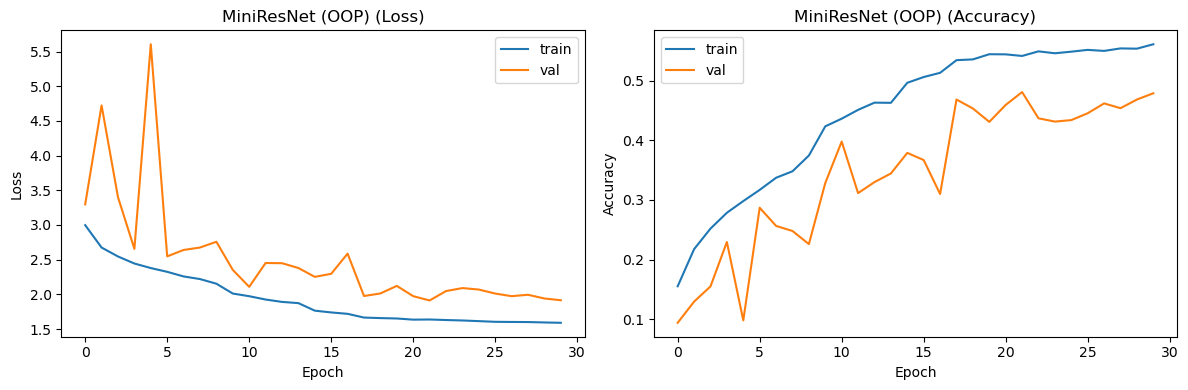

In [9]:
# Save the training-curves figure alongside the cached predictions.

fig = plot_history(history, "MiniResNet (OOP)")
fig.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")


## 5. Evaluation on the test set

Reload the best checkpoint and score it on the held-out split. Because the classes and the loss are registered, `keras.models.load_model` resolves them without a `custom_objects` argument.

Below the metrics we compare this number against the other notebooks. The question we want the report to answer is: how much of the distance from the Sequential baseline to the transfer-learning models is bought by residual connections and BatchNorm alone, without any ImageNet prior?



--------- Classification report ---------
Top-1: 0.4833  Top-3: 0.7116  Top-5: 0.8236
macro-F1: 0.4750    weighted-F1: 0.4902

                       precision    recall  f1-score   support

       Albrecht_Durer       0.62      0.61      0.62        87
      Boris_Kustodiev       0.32      0.44      0.37        66
     Camille_Pissarro       0.35      0.47      0.40        93
        Childe_Hassam       0.27      0.43      0.33        58
         Claude_Monet       0.58      0.43      0.49       140
          Edgar_Degas       0.35      0.30      0.32        64
        Eugene_Boudin       0.55      0.69      0.61        59
         Gustave_Dore       0.69      0.84      0.75        79
           Ilya_Repin       0.46      0.46      0.46        56
      Ivan_Aivazovsky       0.89      0.64      0.74        61
        Ivan_Shishkin       0.44      0.51      0.47        55
  John_Singer_Sargent       0.60      0.44      0.51        82
         Marc_Chagall       0.41      0.42      0.42

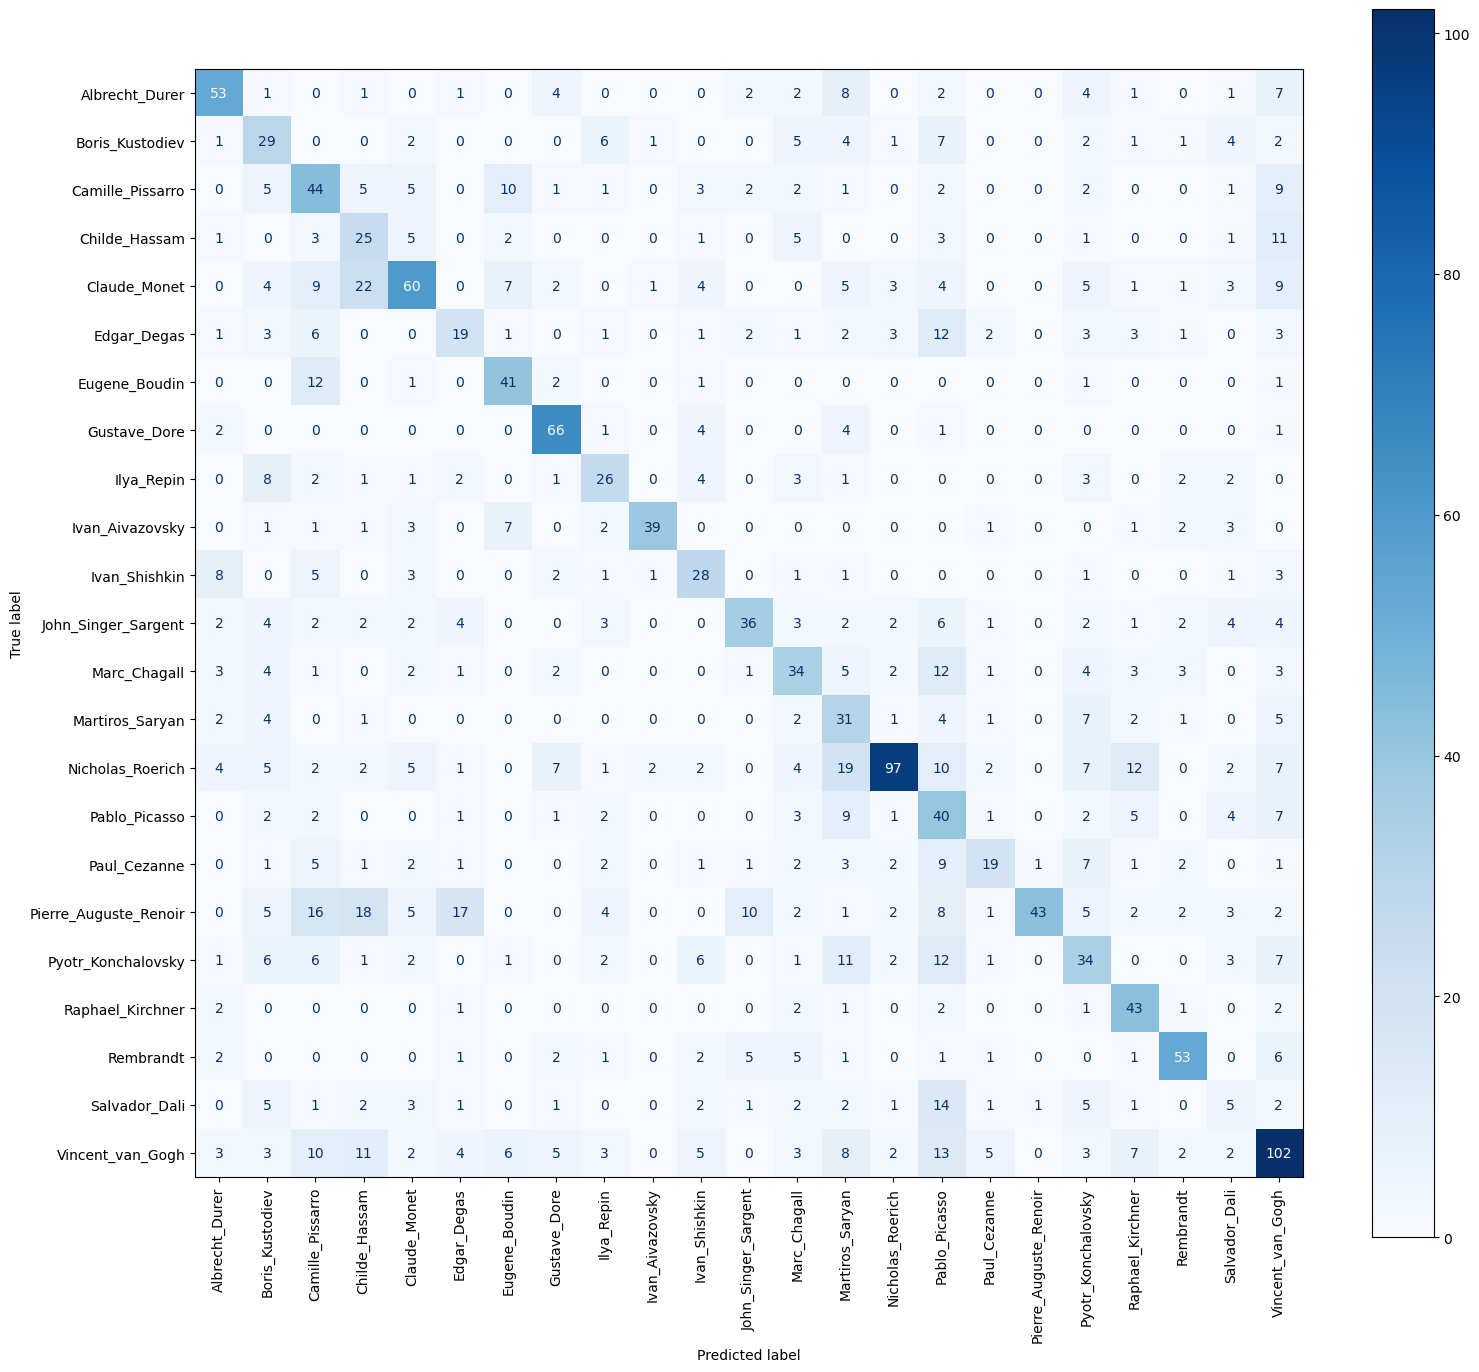

--------- Top 10 misclassifications ---------
                    True class  as  Predicted class                 Count
------------------------------------------------------------------------------------------
                  Claude_Monet  as  Childe_Hassam                   22
              Nicholas_Roerich  as  Martiros_Saryan                 19
         Pierre_Auguste_Renoir  as  Childe_Hassam                   18
         Pierre_Auguste_Renoir  as  Edgar_Degas                     17
         Pierre_Auguste_Renoir  as  Camille_Pissarro                16
                 Salvador_Dali  as  Pablo_Picasso                   14
              Vincent_van_Gogh  as  Pablo_Picasso                   13
                   Edgar_Degas  as  Pablo_Picasso                   12
                 Eugene_Boudin  as  Camille_Pissarro                12
                  Marc_Chagall  as  Pablo_Picasso                   12


In [10]:
# Thanks to @register_keras_serializable, we can reload without custom_objects.
best_model = keras.models.load_model(CKPT_PATH)
oop_results = evaluate_model(best_model, test_ds, class_names)


## 6. Save predictions for the ensemble notebook

Same contract as the other training notebooks. We write softmax probabilities and ground-truth labels to `test_probs.npz`, and the headline metrics to `results.json`, under `outputs/oop_miniresnet/`. Notebook 06 then averages the softmaxes from all four models element-wise to build the ensemble.


In [11]:
# Dump test-set probabilities + metrics for the ensemble notebook.

from sklearn.metrics import f1_score

y_true       = oop_results["y_true"]
y_pred       = oop_results["y_pred"]
y_pred_probs = oop_results["y_pred_probs"]

results = {
    "model":       "MiniResNet (OOP)",
    "api":         "subclassing",
    "img_size":    list(IMG_SIZE),
    "n_params":    int(best_model.count_params()),
    "top1":        oop_results["top_k"][1],
    "top3":        oop_results["top_k"][3],
    "top5":        oop_results["top_k"][5],
    "macro_f1":    oop_results["macro_f1"],
    "weighted_f1": oop_results["weighted_f1"],
}
with open(os.path.join(OUTPUT_DIR, "results.json"), "w") as f:
    json.dump(results, f, indent=2)
np.savez(os.path.join(OUTPUT_DIR, "test_probs.npz"),
         probs=y_pred_probs, y_true=y_true)

print(json.dumps(results, indent=2))


{
  "model": "MiniResNet (OOP)",
  "api": "subclassing",
  "img_size": [
    160,
    160
  ],
  "n_params": 2772215,
  "top1": 0.4832583708145927,
  "top3": 0.7116441779110445,
  "top5": 0.8235882058970515,
  "macro_f1": 0.474993185346951,
  "weighted_f1": 0.4901918296642246
}
